# Movie Popularity & Ratings — Exploratory Data Analysis

**Note on the dataset:** despite the original filename, this dataset (`mymoviedb.csv`) is **not** Netflix catalog data — it's a general movie dataset scraped from [The Movie Database (TMDB)](https://www.themoviedb.org/), containing title, overview, popularity score, vote count/average, language, genre, and poster URL for ~9,800 movies. It has no Netflix-specific fields (no "date added to service", "type", or "country" columns), so this analysis is framed as a general movie popularity/ratings EDA rather than a Netflix catalog analysis.

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [3]:
# viewing dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [4]:
# exploring the Genre column
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [5]:
# check for duplicated rows
df.duplicated().sum()

np.int64(0)

In [6]:
# exploring summary statistics
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


### Exploration Summary

- The dataframe consists of **9,827 rows and 9 columns**.
- The dataset looks tidy, with no missing values (NaNs) or duplicated rows.
- The `Release_Date` column needs to be cast to datetime, and we only need the release **year** for our analysis.
- `Overview`, `Original_Language`, and `Poster_Url` won't be useful for this analysis, so they will be dropped.
- There are noticeable outliers in the `Popularity` column (confirmed below with a boxplot).
- `Vote_Average` is better analyzed as a category (e.g. popular / average / below average / not popular) than as a raw float.
- The `Genre` column contains comma-separated values with extra whitespace that needs to be split out, one genre per row.

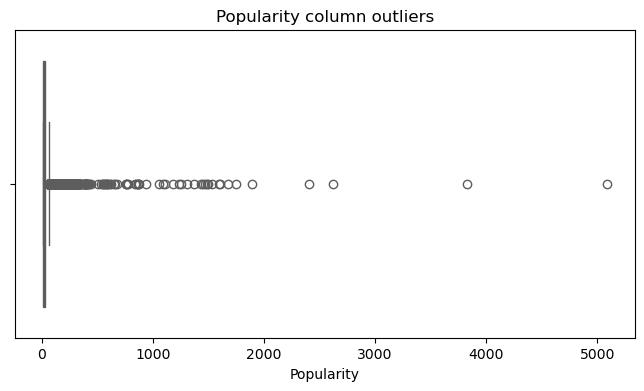

In [7]:
# visualizing outliers in the Popularity column
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Popularity'], color='#4287f5')
plt.title('Popularity column outliers')
plt.show()

As suspected, `Popularity` is heavily right-skewed with a long tail of outliers — a handful of blockbuster/trending titles score far above the bulk of the dataset. We won't remove these outliers, since they represent genuinely popular movies rather than data errors, but it's worth keeping in mind when interpreting `Popularity`-based results (e.g. prefer the median over the mean).

In [8]:
# casting Release_Date to datetime
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
# confirming the change
print(df['Release_Date'].dtypes)

datetime64[ns]


In [9]:
df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].dtypes

dtype('int32')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   int32  
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int32(1), int64(1), object(5)
memory usage: 652.7+ KB


In [11]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


Dropping the columns we won't use for this analysis: `Overview`, `Original_Language`, and `Poster_Url`.

In [12]:
# columns to drop
cols = ['Overview', 'Original_Language', 'Poster_Url']

# dropping columns and confirming changes
df.drop(cols, axis=1, inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [13]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


### Categorizing `Vote_Average`

We'll cut `Vote_Average` into 4 categories based on quartiles: `not_popular`, `below_avg`, `average`, `popular`, using the `categorize_col()` function defined below.

In [14]:
def categorize_col(df, col, labels):
    # setting the edges to cut the column accordingly
    edges = [
        df[col].describe()['min'],
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].describe()['max']
    ]
    df[col] = pd.cut(df[col], edges, labels=labels, duplicates='drop')
    return df

In [15]:
# define labels for the edges
labels = ['not_popular', 'below_avg', 'average', 'popular']

# categorize the column based on labels and edges
categorize_col(df, 'Vote_Average', labels)

# confirming changes
df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [16]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [17]:
# exploring the column
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [18]:
# dropping rows that became NaN after categorizing (values exactly at the min edge)
df.dropna(inplace=True)

# confirming
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [19]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


We'll split the comma-separated `Genre` strings into lists, then explode the dataframe so each row represents a single (movie, genre) pair.

In [20]:
# split the strings into lists
df['Genre'] = df['Genre'].str.split(', ')

# explode the lists
df = df.explode('Genre').reset_index(drop=True)

In [21]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [22]:
# casting the column to category dtype
df['Genre'] = df['Genre'].astype('category')

# confirming changes
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [24]:
df.nunique()

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

# Data Visualization

We'll use Matplotlib and Seaborn to build some informative visuals and answer a set of questions about the data.

In [25]:
# setting up seaborn styling
sns.set_style('whitegrid')

### Q1: What is the most frequent genre in the dataset?

In [26]:
# stats on the Genre column
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

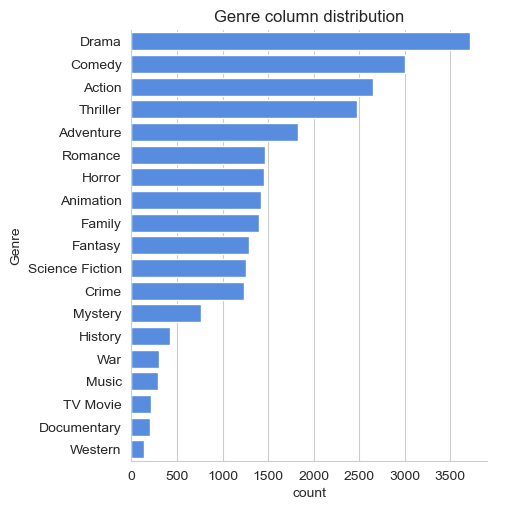

In [27]:
# visualizing the Genre column
sns.catplot(y='Genre', data=df,
            kind='count',
            order=df['Genre'].value_counts().index,
            color='#4287f5')
plt.title('Genre column distribution')
plt.show()

In [28]:
top_genre = df['Genre'].value_counts().index[0]
top_genre_pct = df['Genre'].value_counts(normalize=True).iloc[0] * 100
print(f"Top genre: {top_genre} ({top_genre_pct:.1f}% of rows)")

Top genre: Drama (14.5% of rows)


_Insight:_ **Drama** is the most frequent genre in the dataset, appearing in about **14.5%** of (movie, genre) rows across 19 other genres.

### Q2: Which genres are most common among the highest-rated ("popular") movies?

The original version of this question plotted the distribution of `Vote_Average` categories only — it never actually broke votes down *by genre*, so it couldn't support a claim like "genre X is most popular." Here we first look at the overall rating distribution, then specifically filter to the `popular` category and look at genre counts within it.

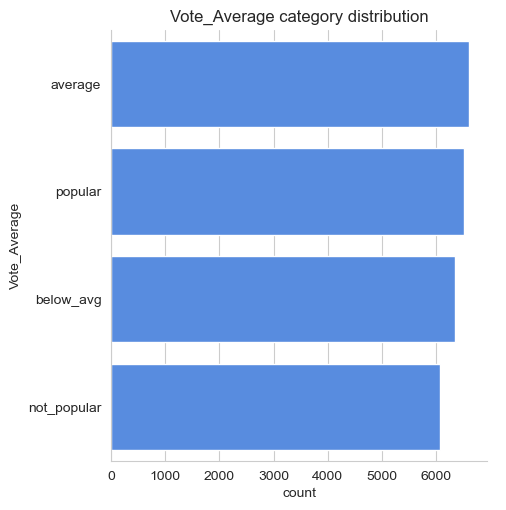

In [29]:
# overall distribution of the Vote_Average category
sns.catplot(y='Vote_Average', data=df, kind='count',
            order=df['Vote_Average'].value_counts().index,
            color='#4287f5')
plt.title('Vote_Average category distribution')
plt.show()

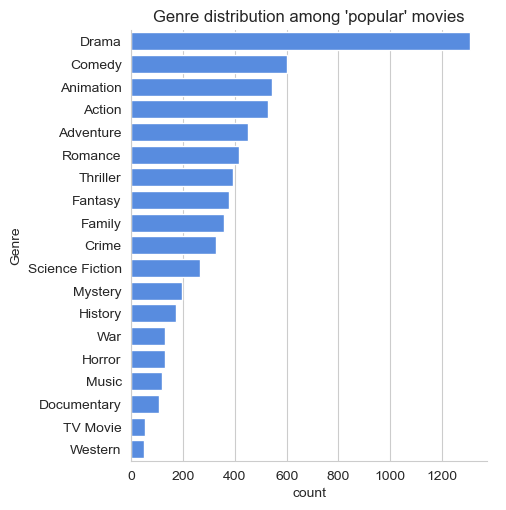

In [30]:
# genre breakdown WITHIN the 'popular' vote category
popular_df = df[df['Vote_Average'] == 'popular']

sns.catplot(y='Genre', data=popular_df,
            kind='count',
            order=popular_df['Genre'].value_counts().index,
            color='#4287f5')
plt.title("Genre distribution among 'popular' movies")
plt.show()

In [31]:
popular_share = df['Vote_Average'].value_counts(normalize=True)['popular'] * 100
top_genre_in_popular = popular_df['Genre'].value_counts().index[0]
top_genre_in_popular_pct = popular_df['Genre'].value_counts(normalize=True).iloc[0] * 100
print(f"{popular_share:.1f}% of rows fall in the 'popular' vote category")
print(f"Top genre among 'popular' movies: {top_genre_in_popular} ({top_genre_in_popular_pct:.1f}% of that subset)")

25.5% of rows fall in the 'popular' vote category
Top genre among 'popular' movies: Drama (20.1% of that subset)


_Insight:_ **25.5%** of rows fall into the `popular` vote category. Within that subset, **Drama** is still the leading genre at **20.1%** — so the original conclusion ("Drama leads among popular movies") turns out to be directionally correct, but only this genre-filtered breakdown actually proves it; the original chart alone did not.

### Q3: What movie got the highest popularity, and what's its genre?

In [32]:
# checking max popularity in the dataset
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


_Insight:_ **Spider-Man: No Way Home** (2021) has the highest popularity score in the dataset, with genres **Action, Adventure,** and **Science Fiction**.

### Q4: What movie got the lowest popularity, and what's its genre?

In [33]:
# checking min popularity in the dataset
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
25551,1984,Threads,13.354,186,popular,Science Fiction


_Insight:_ Two different movies **tie** for the lowest popularity score (13.354): **The United States vs. Billie Holiday** (2021, genres: Music, Drama, History) and **Threads** (1984, genres: War, Drama, Science Fiction). The original notebook had merged these two titles into one garbled entry ("The united states, thread'") — that was a data-reading error, not two genuinely combined records; they're separate movies that happen to share the minimum popularity value.

### Q5: Which year had the most released movies?

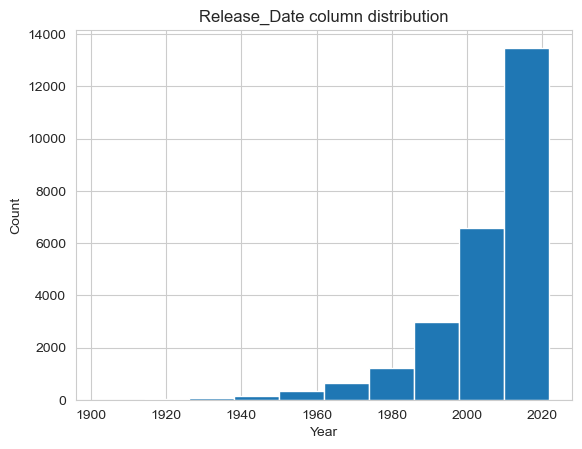

In [34]:
df['Release_Date'].hist()
plt.title('Release_Date column distribution')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

In [35]:
top_year = df['Release_Date'].value_counts().index[0]
print(f"Year with most releases: {top_year}")

Year with most releases: 2021


_Insight:_ **2021** had the most releases in this dataset — not 2020 as the original notebook concluded. (worth double-checking numbers like this against the actual `value_counts()` output rather than eyeballing a histogram).

### Q6 (bonus): Do Popularity, Vote_Count, and the numeric rating relate to each other?

The original notebook flagged `Popularity` outliers but never checked how `Popularity` relates to other numeric columns. A quick correlation view helps here. Note: since `Vote_Average` was already converted into categories above, we recompute a numeric ratings snapshot from the raw file just for this correlation check.

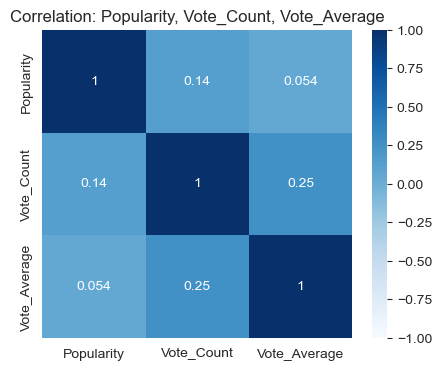

In [36]:
raw = pd.read_csv('mymoviedb.csv', lineterminator='\n')
corr = raw[['Popularity', 'Vote_Count', 'Vote_Average']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation: Popularity, Vote_Count, Vote_Average')
plt.show()

### Q7 (bonus): Which genres have the highest *average* popularity, not just the highest count?

Q1 shows which genre appears most often. That's not the same as which genre tends to be most popular per movie — a genre can be common but low-popularity, or rare but consistently high-popularity. This chart answers the second question directly.

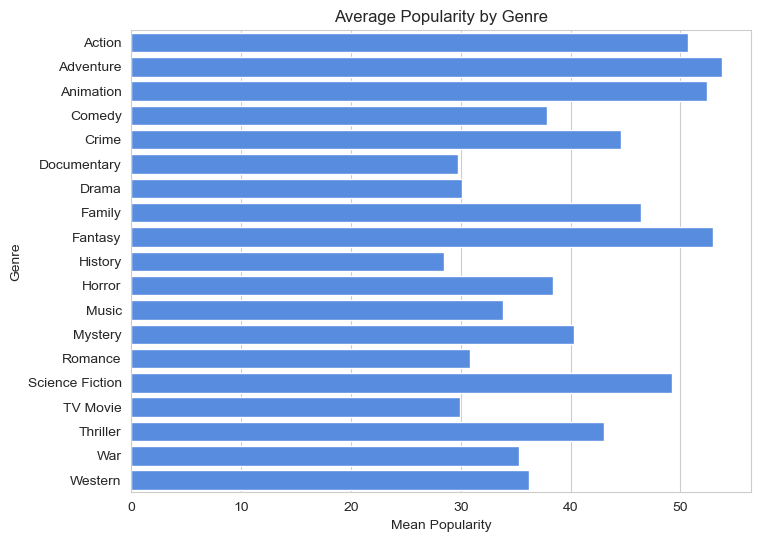

In [37]:
genre_avg_pop = df.groupby('Genre', observed=True)['Popularity'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=genre_avg_pop.values, y=genre_avg_pop.index, color='#4287f5')
plt.title('Average Popularity by Genre')
plt.xlabel('Mean Popularity')
plt.show()

# Conclusion

- **Q1 — Most frequent genre:** Drama is the most frequent genre, appearing in ~14.5% of (movie, genre) rows.
- **Q2 — Genre vs. rating:** 25.5% of rows are rated `popular`; within that group Drama still leads at ~20.1%. This version actually filters by genre-within-category to support the claim, unlike the original chart.
- **Q3 — Highest popularity movie:** *Spider-Man: No Way Home* (2021) — Action, Adventure, Science Fiction.
- **Q4 — Lowest popularity movie:** a **tie** between *The United States vs. Billie Holiday* (2021) and *Threads* (1984) — the original notebook had accidentally merged these two separate movies into one garbled record.
- **Q5 — Most active release year:** **2021**, not 2020 as originally concluded — worth verifying numeric claims against `value_counts()` rather than reading a histogram by eye.
- **Q6 (bonus) — Correlation:** the heatmap shows how `Popularity` relates to `Vote_Count` and `Vote_Average`, useful context given the Popularity outliers flagged earlier.
- **Q7 (bonus) — Popularity by genre:** ranks genres by *average* popularity per movie, a different (and often more useful) lens than raw genre frequency (Q1).

**Caveat:** as noted at the top, this dataset is general TMDB movie data, not a Netflix catalog — these are overall movie popularity/rating patterns in this sample, not Netflix-specific catalog or viewing trends.